In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"     

DEBUG = False    

import glob, math, time
import numpy as np, pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F, torchvision
from sklearn.metrics import roc_curve

assert torch.cuda.is_available(), "No GPU found. Set Accelerator to GPU T4 x2 in Session options."

def find(name):
    hits = glob.glob(f"/kaggle/input/**/{name}", recursive=True)
    assert hits, f"{name} not found. Check that all three inputs are added."
    return hits[0]

images = np.load(find("images_384.npy"), mmap_mode="r")
df = pd.read_csv(find("splits.csv"))
preds = pd.read_csv(find("predictions.csv"))
labels = pd.read_csv(find("stage_2_train_labels.csv"))
boxes = labels[labels.Target == 1]

val = preds[preds.split == "val"]
fpr, tpr, thr = roc_curve(val.target, val.prob)
T = float(thr[np.argmax(tpr - fpr)])
print(f"Decision threshold: {T:.3f}")

pos = preds[(preds.split == "test") & (preds.target == 1)].reset_index(drop=True)
if DEBUG:
    pos = pos.sample(40, random_state=42).reset_index(drop=True)
print("Test patients with pneumonia:", len(pos), "| model said pneumonia for", int((pos.prob >= T).sum()))

S = 384            
K = S / 1024      
rects = {pid: [(math.floor(r.x * K), math.floor(r.y * K), math.ceil((r.x + r.width) * K), math.ceil((r.y + r.height) * K))
               for r in g.itertuples()] for pid, g in boxes.groupby("patientId")}

def box_mask(pid):
    """A 384 x 384 grid that is True inside the radiologists' boxes for this patient."""
    m = np.zeros((S, S), dtype=bool)
    for x0, y0, x1, y1 in rects[pid]:
        m[y0:y1, x0:x1] = True
    return m

train_pos = df[(df.split == "train") & (df.target == 1)].patientId
prior = np.mean([box_mask(pid) for pid in train_pos], axis=0).astype("float32")
pr, pc = np.unravel_index(prior.argmax(), prior.shape)
print(f"Training patients used for the 'usual location' map: {len(train_pos)} | its hottest point: row {pr}, column {pc}")

Decision threshold: 0.212
Test patients with pneumonia: 1203 | model said pneumonia for 959
Training patients used for the 'usual location' map: 4208 | its hottest point: row 208, column 122


In [3]:
model = torchvision.models.densenet121(weights=None)
model.classifier = nn.Linear(model.classifier.in_features, 1)
model.load_state_dict(torch.load(find("densenet121_rsna.pt"), map_location="cuda"))
model = model.cuda().eval()

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).cuda()
STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).cuda()

def prep(batch):
    """uint8 images (N x 384 x 384) -> normalised tensors on the GPU, exactly as in training."""
    x = torch.from_numpy(np.ascontiguousarray(batch)).cuda().float().unsqueeze(1) / 255.0
    return (x.expand(-1, 3, -1, -1) - MEAN) / STD

@torch.no_grad()
def probability(x):
    """Pneumonia probability for already-prepared images, in chunks to fit in GPU memory."""
    out = []
    for i in range(0, len(x), 64):
        with torch.autocast("cuda", dtype=torch.float16):
            out.append(torch.sigmoid(model(x[i:i + 64]).squeeze(1).float()))
    return torch.cat(out).cpu().numpy()

def gradcam(batch):
    """Grad-CAM: which areas of the model's last feature map pushed the pneumonia score up?"""
    x = prep(batch)
    feats = F.relu(model.features(x))                                   # N x 1024 x 12 x 12
    score = model.classifier(F.adaptive_avg_pool2d(feats, 1).flatten(1)).squeeze(1)
    grads = torch.autograd.grad(score.sum(), feats)[0]
    weights = grads.mean(dim=(2, 3), keepdim=True)                      # how much each feature matters
    cam = (weights * feats).sum(1, keepdim=True)                        # N x 1 x 12 x 12
    cam = F.interpolate(cam, size=S, mode="bilinear", align_corners=False).squeeze(1)
    return cam.detach().cpu().numpy(), torch.sigmoid(score).detach().cpu().numpy()

PATCH, STRIDE = 64, 32
corners = [(r, c) for r in range(0, S - PATCH + 1, STRIDE) for c in range(0, S - PATCH + 1, STRIDE)]

def occlusion(img):
    """Occlusion: cover one square at a time and record how much the pneumonia probability falls."""
    x = prep(img[None])                                
    grey = prep(np.full((1, 1, 1), int(img.mean()), dtype=np.uint8)) 
    xs = x.repeat(len(corners) + 1, 1, 1, 1)  
    for k, (r, c) in enumerate(corners, 1):
        xs[k, :, r:r + PATCH, c:c + PATCH] = grey[0]
    p = probability(xs)
    drop = p[0] - p[1:]
    total, count = np.zeros((S, S), "float32"), np.zeros((S, S), "float32")
    for d, (r, c) in zip(drop, corners):
        total[r:r + PATCH, c:c + PATCH] += d
        count[r:r + PATCH, c:c + PATCH] += 1
    return total / count

def hide(img, rect_list):
    """Return a copy of the image with the given rectangles painted the image's average grey."""
    out = np.array(img)
    for x0, y0, x1, y1 in rect_list:
        out[y0:y1, x0:x1] = int(img.mean())
    return out

def control_rects(pid, mask, rng):
    """Rectangles of the same sizes as this patient's boxes, placed at random where there is no box."""
    out, clean = [], True
    for x0, y0, x1, y1 in rects[pid]:
        w, h = min(x1, S) - x0, min(y1, S) - y0
        for _ in range(200):
            cx, cy = int(rng.integers(0, S - w + 1)), int(rng.integers(0, S - h + 1))
            if not mask[cy:cy + h, cx:cx + w].any():
                break
        else:
            clean = False                  
        out.append((cx, cy, cx + w, cy + h))
    return out, clean

def top_pixels(m, k):
    return np.argpartition(m.ravel(), -k)[-k:]

def point_hit(m, mask):
    """Pointing game: is the heatmap's hottest pixel inside a radiologist box?"""
    return bool(mask.ravel()[m.argmax()])

def overlap(m, mask):
    """Take the heatmap's hottest pixels, as many as the boxes cover. What share falls inside the boxes?"""
    return float(mask.ravel()[top_pixels(m, int(mask.sum()))].mean())

x_test = np.stack([images[i] for i in pos.idx.values[:8]])
cam, p_check = gradcam(x_test)
print("Model reloaded. Largest difference from saved predictions:", round(float(np.abs(p_check - pos.prob.values[:8]).max()), 4))
print("Grad-CAM map:", cam.shape, "| occlusion squares per image:", len(corners))

Model reloaded. Largest difference from saved predictions: 0.0014
Grad-CAM map: (8, 384, 384) | occlusion squares per image: 121


In [4]:
import json

rng = np.random.default_rng(42)
rows, cams, occs = [], [], []
start = time.time()

for n, r in enumerate(pos.itertuples(), 1):
    img = np.array(images[r.idx])
    mask = box_mask(r.patientId)
    k = int(mask.sum())

    cam = gradcam(img[None])[0][0]
    occ = occlusion(img)
    g_row, g_col = np.unravel_index(cam.argmax(), cam.shape) 
    o_row, o_col = np.unravel_index(occ.argmax(), occ.shape)

    ctrl, clean = control_rects(r.patientId, mask, rng)
    p_hidden = probability(prep(np.stack([hide(img, rects[r.patientId]), hide(img, ctrl)])))

    rows.append({
        "patientId": r.patientId, "view": r.view, "sex": r.sex, "age": r.age, "n_boxes": r.n_boxes,
        "prob": float(r.prob), "said_pneumonia": bool(r.prob >= T), "box_share": k / S**2,
        "gradcam_hit": point_hit(cam, mask), "gradcam_overlap": overlap(cam, mask),
        "occlusion_hit": point_hit(occ, mask), "occlusion_overlap": overlap(occ, mask),
        "usual_hit": point_hit(prior, mask), "usual_overlap": overlap(prior, mask),
        "methods_agree": len(np.intersect1d(top_pixels(cam, k), top_pixels(occ, k))) / k,
        "gradcam_row": int(g_row), "gradcam_col": int(g_col), "occlusion_row": int(o_row), "occlusion_col": int(o_col),
        "boxes": json.dumps(rects[r.patientId]),
        "prob_boxes_hidden": float(p_hidden[0]), "prob_control_hidden": float(p_hidden[1]), "control_clean": clean,
    })
    cams.append(cam[::4, ::4].astype("float16")); occs.append(occ[::4, ::4].astype("float16"))   # small copies for figures
    if n % 100 == 0 or n == len(pos):
        mins = (time.time() - start) / 60
        print(f"  {n}/{len(pos)} patients, {mins:.1f} min" + (f" | run took about {mins / n * 1203:.0f} min" if DEBUG else ""))

res = pd.DataFrame(rows)
res.to_csv("/kaggle/working/localization_results.csv", index=False)
np.save("/kaggle/working/maps_gradcam.npy", np.stack(cams))
np.save("/kaggle/working/maps_occlusion.npy", np.stack(occs))
np.save("/kaggle/working/map_usual_location.npy", prior)

def summary(d, title):
    print(f"\n{title} ({len(d)} patients)")
    print(f"  Boxes cover {d.box_share.mean():.1%} of the image on average, so a random guess would score about that.")
    print(pd.DataFrame({
        "hottest point inside a box": [d.gradcam_hit.mean(), d.occlusion_hit.mean(), d.usual_hit.mean()],
        "overlap with boxes": [d.gradcam_overlap.mean(), d.occlusion_overlap.mean(), d.usual_overlap.mean()],
    }, index=["Grad-CAM", "Occlusion", "Baseline: usual location"]).round(3).to_string())

summary(res, "All test patients with pneumonia")
summary(res[res.said_pneumonia], "Only those the model correctly called pneumonia")
if (~res.said_pneumonia).sum() > 0:
    summary(res[~res.said_pneumonia], "Only those the model missed")

print(f"\nGrad-CAM and occlusion agreement (shared share of hottest pixels): {res.methods_agree.mean():.3f}")
c = res[res.control_clean]
print(f"\nHiding test ({len(c)} patients where a box-free control position existed):")
print(f"  Average pneumonia probability: original {c.prob.mean():.3f} | boxes hidden {c.prob_boxes_hidden.mean():.3f} | same-size area elsewhere hidden {c.prob_control_hidden.mean():.3f}")
print("\nSaved:", sorted(f for f in os.listdir("/kaggle/working") if not f.startswith(".")))

  100/1203 patients, 1.1 min
  200/1203 patients, 2.2 min
  300/1203 patients, 3.3 min
  400/1203 patients, 4.4 min
  500/1203 patients, 5.6 min
  600/1203 patients, 6.7 min
  700/1203 patients, 7.8 min
  800/1203 patients, 8.9 min
  900/1203 patients, 10.1 min
  1000/1203 patients, 11.2 min
  1100/1203 patients, 12.3 min
  1200/1203 patients, 13.4 min
  1203/1203 patients, 13.4 min

All test patients with pneumonia (1203 patients)
  Boxes cover 11.8% of the image on average, so a random guess would score about that.
                          hottest point inside a box  overlap with boxes
Grad-CAM                                       0.625               0.429
Occlusion                                      0.534               0.339
Baseline: usual location                       0.550               0.425

Only those the model correctly called pneumonia (959 patients)
  Boxes cover 13.1% of the image on average, so a random guess would score about that.
                          hottest 

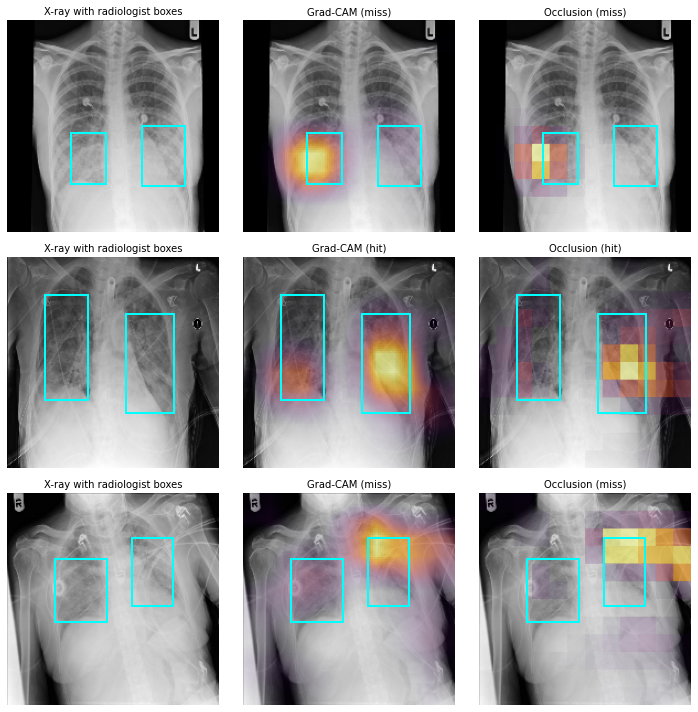

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

show = res[res.said_pneumonia].index[:3]
fig, axes = plt.subplots(3, 3, figsize=(10, 10), dpi=72)
for row, i in zip(axes, show):
    pid = res.patientId[i]
    img = np.array(images[pos.idx[i]])[::2, ::2]                   
    panels = [("X-ray with radiologist boxes", None),
              (f"Grad-CAM ({'hit' if res.gradcam_hit[i] else 'miss'})", cams[i]),
              (f"Occlusion ({'hit' if res.occlusion_hit[i] else 'miss'})", occs[i])]
    for ax, (title, m) in zip(row, panels):
        ax.imshow(img, cmap="gray")
        if m is not None:
            m = np.kron(np.clip(m.astype("float32"), 0, None), np.ones((2, 2)))  
            m = m / m.max() if m.max() > 0 else m
            layer = plt.cm.inferno(m)         
            layer[..., 3] = 0.75 * m           
            ax.imshow(layer)
        for x0, y0, x1, y1 in rects[pid]:
            ax.add_patch(patches.Rectangle((x0 / 2, y0 / 2), (x1 - x0) / 2, (y1 - y0) / 2, fill=False, edgecolor="cyan", linewidth=2))
        ax.set_title(title, fontsize=10); ax.axis("off")
plt.tight_layout()
plt.savefig("/kaggle/working/examples.png", dpi=72)
plt.show()